Task 05: Movie Recommendation System (MovieLens 100K)

Problem Statement: Build a recommendation system that suggests movies to users based on similarity using the MovieLens 100K dataset.

In [16]:
import pandas as pd

ratings = pd.read_csv(
    "u.data",
    sep="\t",
    names=["userId", "movieId", "rating", "timestamp"]
)

print("Ratings shape:", ratings.shape)
ratings.head()

Ratings shape: (100000, 4)


,userId,movieId,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [17]:
movies = pd.read_csv(
    "u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

# u.item has many columns; we only need movieId + title
movies = movies[[0, 1]]
movies.columns = ["movieId", "title"]

print("Movies shape:", movies.shape)
movies.head()

Movies shape: (1682, 2)


,movieId,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [18]:
df = ratings.merge(movies, on="movieId", how="left")

df.head()

,userId,movieId,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [19]:
import numpy as np

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

test_frac = 0.2
train_parts, test_parts = [], []

for uid, grp in df.groupby("userId"):
    grp = grp.sample(frac=1, random_state=42)   # shuffle within user
    n_test = max(1, int(len(grp) * test_frac))
    test_parts.append(grp.iloc[:n_test])
    train_parts.append(grp.iloc[n_test:])

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print("Train:", train_df.shape, "Test:", test_df.shape)

Train: (80367, 5) Test: (19633, 5)


In [20]:
user_item = train_df.pivot_table(
    index="userId",
    columns="movieId",
    values="rating",
    fill_value=0
)

print("User-item matrix shape:", user_item.shape)
user_item.head()

User-item matrix shape: (943, 1647)


movieId,1,2,3,4,5,6,7,8,9,10,...,1671,1672,1673,1674,1675,1676,1677,1678,1679,1680
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,0.0,0.0,3.0,5.0,4.0,1.0,5.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
from sklearn.metrics.pairwise import cosine_similarity

user_sim = cosine_similarity(user_item)
user_sim_df = pd.DataFrame(user_sim, index=user_item.index, columns=user_item.index)

user_sim_df.iloc[:5, :5]

userId,1,2,3,4,5
userId,,,,,
1,1.000000,0.174513,0.025457,0.074561,0.330062
2,0.174513,1.000000,0.082507,0.139654,0.067719
3,0.025457,0.082507,1.000000,0.232400,0.000000
4,0.074561,0.139654,0.232400,1.000000,0.011508
5,0.330062,0.067719,0.000000,0.011508,1.000000


In [22]:
def recommend_user_based(user_id, user_item_matrix, user_sim_df, movies_df, k=10, top_neighbors=20):
    if user_id not in user_item_matrix.index:
        return pd.DataFrame()

    # Similar users (excluding self)
    sims = user_sim_df.loc[user_id].drop(index=user_id).sort_values(ascending=False)
    neighbors = sims.head(top_neighbors)

    # Movies already rated by user in TRAIN
    user_ratings = user_item_matrix.loc[user_id]
    seen_movies = user_ratings[user_ratings > 0].index

    # Weighted score for each movie
    neighbor_ratings = user_item_matrix.loc[neighbors.index]
    weights = neighbors.values.reshape(-1, 1)

    weighted_scores = (neighbor_ratings.values * weights).sum(axis=0)
    norm = np.abs(weights).sum()
    scores = weighted_scores / (norm if norm != 0 else 1)

    scores_series = pd.Series(scores, index=user_item_matrix.columns)
    scores_series = scores_series.drop(index=seen_movies, errors="ignore")

    top_movies = scores_series.sort_values(ascending=False).head(k).reset_index()
    top_movies.columns = ["movieId", "score"]

    # add titles
    top_movies = top_movies.merge(movies_df, on="movieId", how="left")
    return top_movies[["movieId", "title", "score"]]

In [23]:
user_id = 1
recs_user = recommend_user_based(user_id, user_item, user_sim_df, movies, k=10)
recs_user

,movieId,title,score
0,98,"Silence of the Lambs, The (1991)",3.578435
1,96,Terminator 2: Judgment Day (1991),3.528557
2,181,Return of the Jedi (1983),3.317227
3,168,Monty Python and the Holy Grail (1974),3.254879
4,4,Get Shorty (1995),3.064770
5,265,"Hunt for Red October, The (1990)",3.026574
6,318,Schindler's List (1993),3.003126
7,568,Speed (1994),2.910543
8,182,GoodFellas (1990),2.866758
9,655,Stand by Me (1986),2.828179


In [24]:
def precision_at_k(user_id, rec_movie_ids, test_df, k=10, relevant_rating=4):
    true_items = test_df[(test_df["userId"] == user_id) & (test_df["rating"] >= relevant_rating)]["movieId"]
    true_set = set(true_items.tolist())

    if len(true_set) == 0:
        return np.nan

    recs_k = rec_movie_ids[:k]
    hits = sum(1 for m in recs_k if m in true_set)
    return hits / k

In [25]:
def evaluate_user_based_precision(train_df, test_df, movies_df, k=10):
    user_item = train_df.pivot_table(index="userId", columns="movieId", values="rating", fill_value=0)
    user_sim = cosine_similarity(user_item)
    user_sim_df = pd.DataFrame(user_sim, index=user_item.index, columns=user_item.index)

    precisions = []
    for uid in user_item.index:
        recs = recommend_user_based(uid, user_item, user_sim_df, movies_df, k=k)
        rec_ids = recs["movieId"].tolist()
        p = precision_at_k(uid, rec_ids, test_df, k=k)
        if not np.isnan(p):
            precisions.append(p)

    return float(np.mean(precisions)), len(precisions)

p10_user, n_eval = evaluate_user_based_precision(train_df, test_df, movies, k=10)
print(f"User-based Mean Precision@10: {p10_user:.4f} (users evaluated: {n_eval})")

User-based Mean Precision@10: 0.2399 (users evaluated: 924)


In [26]:
item_sim = cosine_similarity(user_item.T)
item_sim_df = pd.DataFrame(item_sim, index=user_item.columns, columns=user_item.columns)

def recommend_item_based(user_id, user_item_matrix, item_sim_df, movies_df, k=10):
    if user_id not in user_item_matrix.index:
        return pd.DataFrame()

    user_ratings = user_item_matrix.loc[user_id]
    seen = user_ratings[user_ratings > 0]

    scores = pd.Series(0.0, index=user_item_matrix.columns)
    for movie_id, rating in seen.items():
        scores += item_sim_df[movie_id] * rating

    scores = scores.drop(index=seen.index, errors="ignore")
    top = scores.sort_values(ascending=False).head(k).reset_index()
    top.columns = ["movieId", "score"]
    top = top.merge(movies_df, on="movieId", how="left")
    return top[["movieId", "title", "score"]]

In [27]:
def evaluate_item_based_precision(train_df, test_df, movies_df, k=10):
    user_item = train_df.pivot_table(index="userId", columns="movieId", values="rating", fill_value=0)
    item_sim = cosine_similarity(user_item.T)
    item_sim_df = pd.DataFrame(item_sim, index=user_item.columns, columns=user_item.columns)

    precisions = []
    for uid in user_item.index:
        recs = recommend_item_based(uid, user_item, item_sim_df, movies_df, k=k)
        rec_ids = recs["movieId"].tolist()
        p = precision_at_k(uid, rec_ids, test_df, k=k)
        if not np.isnan(p):
            precisions.append(p)

    return float(np.mean(precisions)), len(precisions)

p10_item, n_eval_item = evaluate_item_based_precision(train_df, test_df, movies, k=10)
print(f"Item-based Mean Precision@10: {p10_item:.4f} (users evaluated: {n_eval_item})")

Item-based Mean Precision@10: 0.2297 (users evaluated: 924)


In [28]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=20, random_state=42)
user_factors = svd.fit_transform(user_item)
item_factors = svd.components_

pred = np.dot(user_factors, item_factors)
pred_df = pd.DataFrame(pred, index=user_item.index, columns=user_item.columns)

def recommend_svd(user_id, user_item_matrix, pred_df, movies_df, k=10):
    if user_id not in user_item_matrix.index:
        return pd.DataFrame()

    seen = user_item_matrix.loc[user_id]
    seen_movies = seen[seen > 0].index

    scores = pred_df.loc[user_id].drop(index=seen_movies, errors="ignore")
    top = scores.sort_values(ascending=False).head(k).reset_index()
    top.columns = ["movieId", "score"]
    top = top.merge(movies_df, on="movieId", how="left")
    return top[["movieId", "title", "score"]]

In [29]:
def evaluate_svd_precision(train_df, test_df, movies_df, k=10, n_components=20):
    user_item = train_df.pivot_table(index="userId", columns="movieId", values="rating", fill_value=0)

    svd = TruncatedSVD(n_components=n_components, random_state=42)
    user_factors = svd.fit_transform(user_item)
    item_factors = svd.components_
    pred = np.dot(user_factors, item_factors)
    pred_df = pd.DataFrame(pred, index=user_item.index, columns=user_item.columns)

    precisions = []
    for uid in user_item.index:
        recs = recommend_svd(uid, user_item, pred_df, movies_df, k=k)
        rec_ids = recs["movieId"].tolist()
        p = precision_at_k(uid, rec_ids, test_df, k=k)
        if not np.isnan(p):
            precisions.append(p)

    return float(np.mean(precisions)), len(precisions)

p10_svd, n_eval_svd = evaluate_svd_precision(train_df, test_df, movies, k=10, n_components=20)
print(f"SVD Mean Precision@10: {p10_svd:.4f} (users evaluated: {n_eval_svd})")

SVD Mean Precision@10: 0.2649 (users evaluated: 924)


The recommendation system was implemented using user-based collaborative filtering, item-based collaborative filtering, and matrix factorization using SVD. The evaluation using Precision@10 showed that SVD achieved the highest performance (0.2649), outperforming both user-based (0.2399) and item-based methods (0.2297). This indicates that latent factor models capture user preferences more effectively than similarity-based approaches.

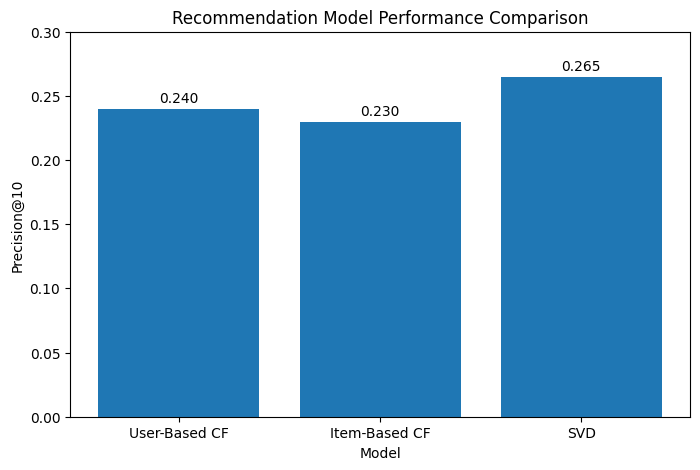

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

results = pd.DataFrame({
    "Model": ["User-Based CF", "Item-Based CF", "SVD"],
    "Precision@10": [0.2399, 0.2297, 0.2649]
})

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Precision@10"])

plt.title("Recommendation Model Performance Comparison")
plt.ylabel("Precision@10")
plt.xlabel("Model")
plt.ylim(0,0.30)

for i, v in enumerate(results["Precision@10"]):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.show()